# Notebook 10 – Adaptive Decision Engine

Simulate the **adaptive decision engine** before integration into the React e-commerce website.

This notebook validates that the layered adaptation architecture works correctly.

- No LLM
- No React code
- Only assembles the final UI configuration from repository JSON files

**Pipeline order:**

1. Detect Device
2. Load Global Defaults
3. Load Device Defaults
4. Apply Persona Overrides
5. Apply Mood Overrides
6. Apply Personality Nudges
7. Produce Final UI Configuration

## Inputs

- `data/outputs/global_defaults.json`
- `data/outputs/desktop_defaults.json`
- `data/outputs/mobile_defaults.json`
- `data/outputs/persona_overrides.json`
- `data/outputs/mood_overrides.json`
- `data/outputs/trait_modifiers.json`

## Outputs

- `data/outputs/adaptive_engine/final_ui_configuration.json`
- `data/outputs/adaptive_engine/adaptation_log.json`
- `reports/AdaptiveDecisionEngine/simulation_results.xlsx`
- `reports/AdaptiveDecisionEngine/figures/`

In [1]:
import json
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _bootstrap_project() -> Path:
    search_from = Path.cwd().resolve()
    candidates = [search_from, *search_from.parents]
    nested_root = search_from / "EvidenceBasedAdaptiveUI"
    if (nested_root / "src" / "config.py").exists():
        candidates.insert(0, nested_root)
    for candidate in candidates:
        if (candidate / "src" / "config.py").exists():
            root = str(candidate)
            if root not in sys.path:
                sys.path.insert(0, root)
            return candidate
    raise FileNotFoundError("Could not find project root containing src/config.py.")


PROJECT_ROOT = _bootstrap_project()

from src.adaptive_engine import (
    UserContext,
    export_results,
    generate_random_contexts,
    load_repositories,
    run_adaptive_engine,
    run_batch_simulation,
)
from src.adaptive_engine.adaptive_engine import load_and_validate
from src.adaptive_engine.logger import format_log_text

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

INPUT_DIR = PROJECT_ROOT / "data" / "outputs"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "adaptive_engine"
REPORTS_DIR = PROJECT_ROOT / "reports" / "AdaptiveDecisionEngine"
FIGURES_DIR = REPORTS_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Reports: {REPORTS_DIR}")

Input directory: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs
Output directory: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/adaptive_engine
Reports: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveDecisionEngine


## Simulation input

Replace this object with other test cases.

In [2]:
USER_CONTEXT = UserContext(
    persona="Explorer",
    mood="Happy",
    device="Desktop",
    personality={
        "Extraversion": "High",
        "Agreeableness": "Medium",
        "Conscientiousness": "High",
        "Neuroticism": "Low",
        "Openness": "High",
    },
)

print(json.dumps(
    {
        "persona": USER_CONTEXT.persona,
        "mood": USER_CONTEXT.mood,
        "device": USER_CONTEXT.device,
        "personality": USER_CONTEXT.personality,
    },
    indent=2,
))

{
  "persona": "Explorer",
  "mood": "Happy",
  "device": "Desktop",
  "personality": {
    "Extraversion": "High",
    "Agreeableness": "Medium",
    "Conscientiousness": "High",
    "Neuroticism": "Low",
    "Openness": "High"
  }
}


## Step 1 — Read all repositories

Validate they exist. Report missing repositories.

In [3]:
bundle, load_report, repo_validation = load_and_validate(INPUT_DIR)

print(load_report.summary())
print("\nLoaded files:")
for filename in load_report.loaded_files:
    print(f"  ✓ {filename}")

if load_report.missing_files:
    print("\nMissing files:")
    for filename in load_report.missing_files:
        print(f"  ✗ {filename}")
    raise FileNotFoundError("Cannot continue — repository files missing.")

print("\nRepository validation:")
display(pd.DataFrame(repo_validation.checks))

All 6 repository files loaded from /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs

Loaded files:
  ✓ global_defaults.json
  ✓ desktop_defaults.json
  ✓ mobile_defaults.json
  ✓ persona_overrides.json
  ✓ mood_overrides.json
  ✓ trait_modifiers.json

Repository validation:


,check,passed,detail
0,All JSON files successfully loaded,True,All 6 repository files loaded from /Users/mari...
1,File exists: global_defaults.json,True,ok
2,File exists: desktop_defaults.json,True,ok
3,File exists: mobile_defaults.json,True,ok
4,File exists: persona_overrides.json,True,ok
5,File exists: mood_overrides.json,True,ok
6,File exists: trait_modifiers.json,True,ok


## Steps 2–3 — Load defaults and build Base UI

- **Desktop** → `desktop_defaults.json` merged with global defaults
- **Smartphone** → `mobile_defaults.json` merged with global defaults

In [4]:
result = run_adaptive_engine(USER_CONTEXT, bundle)

print(f"Device detected: {result.context['device']}")
print(f"Defaults source: global_defaults.json + {result.context['device_defaults']}")
print(f"Base UI elements: {len(result.base_ui)}")
display(pd.DataFrame([{"ui_element": k, "value": v} for k, v in list(result.base_ui.items())[:10]]))

Device detected: Desktop
Defaults source: global_defaults.json + desktop_defaults.json
Base UI elements: 27


,ui_element,value
0,accent_color_pref,"Blue (Trustworthy, professional, calm)"
1,background_pref,"Cream/Off-white (Warm, comfortable, paper-like)"
2,button_style_pref,"Rounded Corners (Soft, modern rounded edges)"
3,checkout_style,One Page (All checkout steps on a single scrol...
4,color_theme_pref,"Minimalist Black & White (Clean, high contrast..."
5,desktop_category_display,Visual Grid (Category tiles with images)
6,desktop_filter_location,Sidebar Left (Permanent filter panel on the le...
7,desktop_grid_pref,"3 Columns (Balanced view, moderate item size)"
8,desktop_image_text_ratio,"Image-focused (80% images, 20% text - highly v..."
9,desktop_info_density,"Moderate (Balanced - some details visible, cli..."


## Steps 4–5 — Persona and mood overrides

Persona overrides replace only matching properties. Mood overrides overwrite persona values on the same property. Every override is logged.

In [5]:
print(f"Persona overrides applied: {result.metadata['n_persona_overrides']}")
if result.persona_applied:
    display(pd.DataFrame(result.persona_applied))

print(f"\nMood overrides applied: {result.metadata['n_mood_overrides']}")
if result.mood_applied:
    display(pd.DataFrame(result.mood_applied))

Persona overrides applied: 7


,layer,ui_element,previous,value,confidence
0,persona,font_style_pref,2. Classic Serif (Traditional fonts with decor...,"1. Modern Sans-serif (Clean, contemporary font...",0.300000
1,persona,color_theme_pref,"Minimalist Black & White (Clean, high contrast...","Vibrant Bold (Bright, energetic colors - excit...",0.300000
2,persona,urgency_pref,Both (Show both stock and time based urgency),None (I find these annoying and manipulative),0.333333
3,persona,form_field_style,Rounded Border Fields (Outlined field with rou...,Outlined (Border around the field),0.300000
4,persona,desktop_navigation,Top Bar (Categories always visible across the ...,Mega Menu (Dropdown with images and subcategor...,0.333333
5,persona,desktop_review_display,Recent 3- 5 (Show a few recent reviews),All Paginated (Show all reviews with pagination),0.566667
6,persona,mobile_sticky_header,None,No (Header scrolls away with content),0.533333



Mood overrides applied: 6


,layer,ui_element,previous,value,confidence
0,mood,checkout_style,One Page (All checkout steps on a single scrol...,Progress Bar (Multi step with visual progress ...,0.588235
1,mood,desktop_grid_pref,"3 Columns (Balanced view, moderate item size)","2 Columns (Large product images, fewer items p...",0.352941
2,mood,desktop_search_visibility,"Always Visible Top (Large, prominent search ba...",Collapsible (Search bar that expands when clic...,0.764706
3,mood,desktop_price_display,With Savings Highlighted (Shows discount amoun...,With Comparison (Shows similar products' prices),0.411765
4,mood,desktop_filter_location,Sidebar Left (Permanent filter panel on the le...,Top Bar (Filters displayed across the top),0.470588
5,mood,mobile_category_display,None,Visual Grid (Category tiles with images),0.352941


## Step 6 — Personality nudges

Nudges never replace categorical UI decisions. They only adjust supported style properties:
information density, animation, visual richness, social proof, recommendation strength, whitespace, typography scale.

In [6]:
active_nudges = [n for n in result.nudges_applied if n.get("status") != "skipped"]
print(f"Trait nudges applied: {len(active_nudges)}")
if active_nudges:
    display(pd.DataFrame(active_nudges))

print("\nNudge summary (net adjustments):")
print(json.dumps(result.nudge_summary, indent=2))

Trait nudges applied: 5


,trait,level,property,ui_element,delta,previous,previous_index,new_index,value,confidence
0,Extraversion,High,recommendation_strength,social_proof_display,-1,User Photos (Photos uploaded by customers),4,3,Customer Reviews (Written reviews with ratings),0.606754
1,Extraversion,High,information_density,desktop_info_density,-1,"Moderate (Balanced - some details visible, cli...",1,0,"Minimal (Only key information - product name, ...",0.606754
2,Conscientiousness,High,information_density,desktop_info_density,1,"Minimal (Only key information - product name, ...",0,1,"Moderate (Balanced - some details visible, cli...",0.272673
3,Openness,High,visual_richness,desktop_image_text_ratio,1,"Image-focused (80% images, 20% text - highly v...",2,2,"Image-focused (80% images, 20% text - highly v...",0.405088
4,Openness,High,visual_richness,hero_banner_size,1,Medium Split (Takes up half the screen),2,3,Large Full screen (Takes up entire first screen),0.405088



Nudge summary (net adjustments):
{
  "visual_richness": "+1",
  "information_density": "0",
  "whitespace": "0",
  "animation": "0",
  "recommendation_strength": "-1"
}


## Step 7 — Final Adaptive UI Configuration

In [7]:
print(json.dumps(result.final_ui_configuration, indent=2))

{
  "accent_color": "Blue",
  "animation": "0",
  "background": "Cream/Off-white",
  "button_style": "Rounded Corners",
  "category_display": "Visual Grid",
  "checkout": "Progress Bar",
  "color_theme": "Vibrant Bold",
  "filter_location": "Top Bar",
  "font_style": "Modern Sans-serif",
  "form_field": "Outlined",
  "grid_layout": "2 Columns",
  "hero_banner": "Large Full screen",
  "information_density": "0",
  "information_density_level": "Moderate",
  "layout_whitespace": "Balanced",
  "navigation": "Mega Menu",
  "persistent_filters": "Yes",
  "price_display": "With Comparison",
  "product_card": "Info Rich",
  "product_description": "Expandable Sections",
  "quick_view": "Sidebar Slide",
  "recommendation": "Deals",
  "recommendation_strength": "-1",
  "review_display": "All Paginated",
  "search_visibility": "Collapsible",
  "social_proof": "Customer Reviews",
  "typography_scale": "Large",
  "urgency": "None",
  "visual_balance": "Image-focused",
  "visual_richness": "+1",
  "w

## Step 8 — Adaptation Log

In [8]:
print(format_log_text(result.adaptation_log))
print("\n--- Structured log ---")
display(pd.DataFrame(result.adaptation_log["entries"]))

Loaded Global Defaults
Loaded Desktop Defaults
Applied Persona Override
  font_style_pref
  Classic Serif
  ↓
  Modern Sans-serif

Applied Persona Override
  color_theme_pref
  Minimalist Black & White
  ↓
  Vibrant Bold

Applied Persona Override
  urgency_pref
  Both
  ↓
  None

Applied Persona Override
  form_field_style
  Rounded Border Fields
  ↓
  Outlined

Applied Persona Override
  desktop_navigation
  Top Bar
  ↓
  Mega Menu

Applied Persona Override
  desktop_review_display
  Recent 3- 5
  ↓
  All Paginated

Applied Persona Override
  mobile_sticky_header
  Default
  ↓
  No

Applied Mood Override
  checkout_style
  One Page
  ↓
  Progress Bar

Applied Mood Override
  desktop_grid_pref
  3 Columns
  ↓
  2 Columns

Applied Mood Override
  desktop_search_visibility
  Always Visible Top
  ↓
  Collapsible

Applied Mood Override
  desktop_price_display
  With Savings Highlighted
  ↓
  With Comparison

Applied Mood Override
  desktop_filter_location
  Sidebar Left
  ↓
  Top Bar

Appl

,step,layer,detail,device,property,before,after,arrow,ui_element,trait,level
0,Loaded Global Defaults,defaults,Merged global_defaults.json with base survey m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Loaded Desktop Defaults,device_defaults,Applied desktop_defaults.json.json on top of g...,Desktop,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Applied Persona Override,persona,NaN,NaN,font_style_pref,Classic Serif,Modern Sans-serif,Classic Serif → Modern Sans-serif,NaN,NaN,NaN
3,Applied Persona Override,persona,NaN,NaN,color_theme_pref,Minimalist Black & White,Vibrant Bold,Minimalist Black & White → Vibrant Bold,NaN,NaN,NaN
4,Applied Persona Override,persona,NaN,NaN,urgency_pref,Both,None,Both → None,NaN,NaN,NaN
5,Applied Persona Override,persona,NaN,NaN,form_field_style,Rounded Border Fields,Outlined,Rounded Border Fields → Outlined,NaN,NaN,NaN
6,Applied Persona Override,persona,NaN,NaN,desktop_navigation,Top Bar,Mega Menu,Top Bar → Mega Menu,NaN,NaN,NaN
7,Applied Persona Override,persona,NaN,NaN,desktop_review_display,Recent 3- 5,All Paginated,Recent 3- 5 → All Paginated,NaN,NaN,NaN
8,Applied Persona Override,persona,NaN,NaN,mobile_sticky_header,Default,No,Default → No,NaN,NaN,NaN
9,Applied Mood Override,mood,NaN,NaN,checkout_style,One Page,Progress Bar,One Page → Progress Bar,NaN,NaN,NaN


## Step 9 — Export JSON

In [9]:
export_paths = export_results(result, OUTPUT_DIR)
for label, path in export_paths.items():
    print(f"Exported {label}: {path}")

Exported final_ui_configuration: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/adaptive_engine/final_ui_configuration.json
Exported adaptation_log: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/data/outputs/adaptive_engine/adaptation_log.json


## Step 10 — Batch simulation (20 random users)

In [10]:
random_contexts = generate_random_contexts(bundle, n=20, seed=42)
batch_results, simulation_df = run_batch_simulation(random_contexts, bundle)

simulation_xlsx = REPORTS_DIR / "simulation_results.xlsx"
with pd.ExcelWriter(simulation_xlsx, engine="openpyxl") as writer:
    simulation_df.to_excel(writer, sheet_name="simulations", index=False)
    pd.DataFrame([{"ui_element": k, "value": v} for k, v in result.raw_ui_configuration.items()]).to_excel(
        writer, sheet_name="example_raw_ui", index=False
    )
    pd.DataFrame([{"component": k, "value": v} for k, v in result.final_ui_configuration.items()]).to_excel(
        writer, sheet_name="example_final_ui", index=False
    )

display(simulation_df[[
    "simulation_id", "device", "persona", "mood",
    "n_persona_overrides", "n_mood_overrides", "n_trait_nudges", "validation_ok",
]])
print(f"\nSaved: {simulation_xlsx}")

,simulation_id,device,persona,mood,n_persona_overrides,n_mood_overrides,n_trait_nudges,validation_ok
0,1,Desktop,Deal Hunter,Happy,3,6,8,True
1,2,Desktop,Browser,Sad,7,0,10,True
2,3,Desktop,Minimalist,Bored,2,4,5,True
3,4,Smartphone,Deal Hunter,Stressed,3,6,8,True
4,5,Desktop,Impulsive Buyer,Frustrated,6,0,3,True
5,6,Smartphone,Impulsive Buyer,Relaxed,6,4,5,True
6,7,Smartphone,Loyal Customer,Excited,9,4,9,True
7,8,Desktop,Researcher,Excited,6,4,10,True
8,9,Smartphone,Browser,Sad,7,0,6,True
9,10,Smartphone,Impulsive Buyer,Happy,6,6,1,True



Saved: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveDecisionEngine/simulation_results.xlsx


## Visualizations

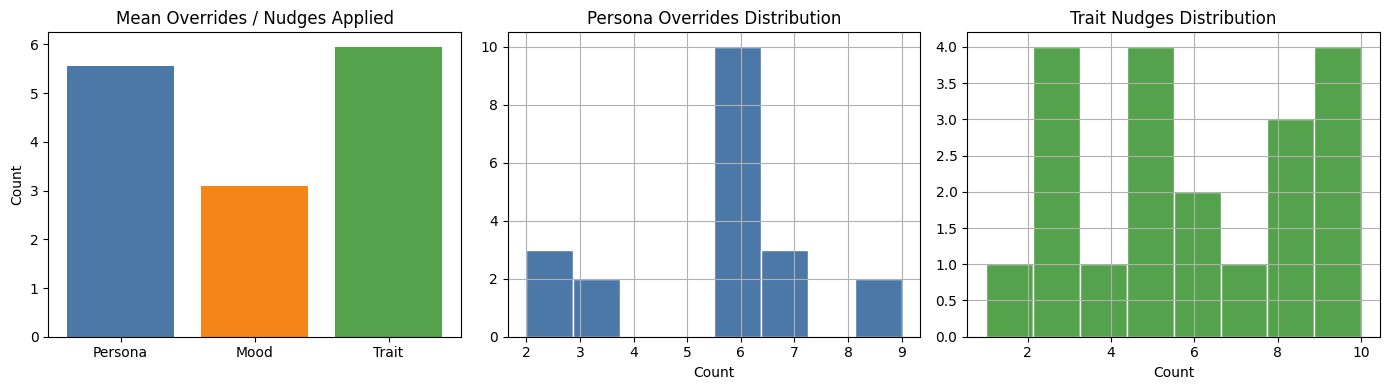

Saved: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveDecisionEngine/figures/override_and_nudge_counts.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(
    ["Persona", "Mood", "Trait"],
    [
        simulation_df["n_persona_overrides"].mean(),
        simulation_df["n_mood_overrides"].mean(),
        simulation_df["n_trait_nudges"].mean(),
    ],
    color=["#4C78A8", "#F58518", "#54A24B"],
)
axes[0].set_title("Mean Overrides / Nudges Applied")
axes[0].set_ylabel("Count")

simulation_df["n_persona_overrides"].hist(ax=axes[1], bins=8, color="#4C78A8", edgecolor="white")
axes[1].set_title("Persona Overrides Distribution")
axes[1].set_xlabel("Count")

simulation_df["n_trait_nudges"].hist(ax=axes[2], bins=8, color="#54A24B", edgecolor="white")
axes[2].set_title("Trait Nudges Distribution")
axes[2].set_xlabel("Count")

plt.tight_layout()
override_fig = FIGURES_DIR / "override_and_nudge_counts.png"
plt.savefig(override_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {override_fig}")

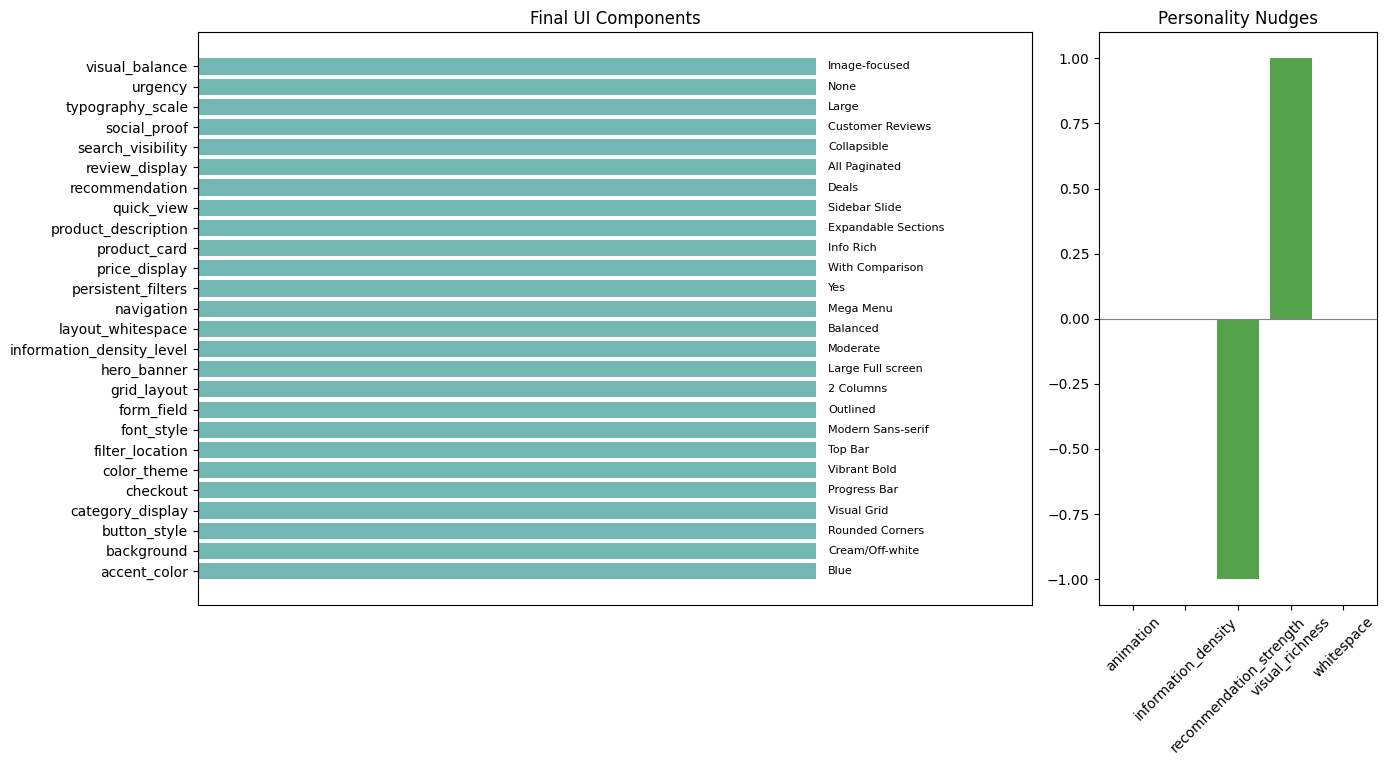

Saved: /Users/mariam/Downloads/Trial-Guide/EvidenceBasedAdaptiveUI/reports/AdaptiveDecisionEngine/figures/final_ui_components.png


In [15]:
components = pd.Series(result.final_ui_configuration).sort_index()
nudge_keys = {"animation", "information_density", "recommendation_strength", "visual_richness", "whitespace"}
ui_components = components[~components.index.isin(nudge_keys)]
nudge_components = components[components.index.isin(nudge_keys)]

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(components) * 0.25)), gridspec_kw={"width_ratios": [3, 1]})

y_pos = range(len(ui_components))
axes[0].barh(list(y_pos), [1] * len(ui_components), color="#72B7B2")
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(ui_components.index)
axes[0].set_xlim(0, 1.35)
axes[0].set_xticks([])
axes[0].set_title("Final UI Components")
for i, value in enumerate(ui_components.values):
    axes[0].text(1.02, i, str(value), va="center", fontsize=8)

if len(nudge_components):
    nudge_values = [int(v) for v in nudge_components.values]
    axes[1].bar(nudge_components.index, nudge_values, color="#54A24B")
    axes[1].axhline(0, color="gray", linewidth=0.8)
    axes[1].set_title("Personality Nudges")
    axes[1].tick_params(axis="x", rotation=45)
else:
    axes[1].set_visible(False)

plt.tight_layout()
components_fig = FIGURES_DIR / "final_ui_components.png"
plt.savefig(components_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {components_fig}")

## Validation

In [13]:
validation_df = pd.DataFrame(result.validation["checks"])
display(validation_df)

all_batch_valid = simulation_df["validation_ok"].all()
print(f"\nAll batch simulations valid: {all_batch_valid}")
if result.warnings:
    print("Warnings:", result.warnings)

,check,passed,detail
0,No duplicate properties,True,"29 keys, 29 unique"
1,No missing UI property values,True,0 empty values
2,All required global UI elements exist,True,all present
3,All required Desktop UI elements exist,True,all present



All batch simulations valid: True
Warnings: ["No trait nudges found for Neuroticism = 'Low'."]


## Final summary

In [14]:
print("Simulation Successful")
print("Repository Loaded")
print("Final UI Generated")
print(f"Number of Persona Overrides Applied: {result.metadata['n_persona_overrides']}")
print(f"Number of Mood Overrides Applied: {result.metadata['n_mood_overrides']}")
print(f"Number of Nudges Applied: {result.metadata['n_trait_nudges']}")
print("Export completed successfully.")

Simulation Successful
Repository Loaded
Final UI Generated
Number of Persona Overrides Applied: 7
Number of Mood Overrides Applied: 6
Number of Nudges Applied: 5
Export completed successfully.
